# Downsample vibration CSVs to 30-minute cadence

This notebook inspects **`TIMESTAMP`** in sensor CSVs (e.g. `data/AHU_2_9_Blower_DE_A.csv`) and writes **30-minute** series to **`data_30mins_frequency/`**.

## What we found in `AHU_2_9_Blower_DE_A.csv`

- **~61.8k rows**, `2023-08-25` → `2026-01-20`, day-first timestamps parse cleanly.
- **Median step ≈ 300 s (5 min)** — ~95% of consecutive gaps are 300 s ± 30 s.
- Also **600 s, 1800 s, duplicates (0 s)**, and **long outages** (max gap ~471 days after the first sparse point).

## Downsampling methods (important)

| Method | Changes sensor values? | What it does |
|--------|------------------------|--------------|
| **`pick_last_in_bin` (default)** | **No** — keeps real rows | Sort by time, assign each row to a 30-minute clock bin, keep the **last** original row in each bin (all columns unchanged). |
| **`pick_first_in_bin`** | **No** | Same, but **first** row in each bin. |
| **`strict_incoming`** | **No** | Drop rows unless the previous **kept** row is ~30 min earlier (chain filter; like `filter_csvs_to_5min_cadence.ipynb`). |
| **`resample_mean`** | **Yes** | Averages numeric columns per 30-min bin (values are **not** from a single measurement). |

If you only want **fewer rows at ~30 min spacing without editing readings**, use **`pick_last_in_bin`** or **`strict_incoming`**, not `resample_mean`.

Adjust paths in the next cell. Run all cells top to bottom.

In [8]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
OUT_DIR = REPO_ROOT / "data_30mins_frequency"

# Primary file to inspect in the EDA section (change as needed).
SAMPLE_CSV = DATA_DIR / "AHU_2_9_Blower_DE_A.csv"

TIME_COL = "TIMESTAMP"
TARGET_STEP_SECONDS = 30 * 60  # 1800 s
STEP_TOL_SECONDS = 60.0  # for strict_incoming mode only

# pick_last_in_bin | pick_first_in_bin | strict_incoming | resample_mean
DOWNSAMPLE_METHOD = "pick_last_in_bin"

# Batch: process every *.csv in DATA_DIR (set False to only process SAMPLE_CSV).
BATCH_ALL_CSVS = True
RECURSIVE = False

# Output filename: <stem>_30_min.csv (set "" to keep source basename)
OUT_STEM_SUFFIX = "_30_min"

## Process a multi-sensor export (e.g. `data/Jan2Jun.csv`)

Multi-sensor files have **many sensors in one CSV**. The downsampler expects **one sensor per file** (sorted by `TIMESTAMP`).

1. Set **`MULTI_SENSOR_CSV`** in the split cell (default: `data/Jan2Jun.csv`).
2. Run the **split** cell → `data/jan2jun_by_sensor/<stem>.csv` (uses `SENSOR_DESC` or `SENSOR_NAME`; renames `DATA12` → `Acceleration RMS`).
3. Run **§3 Write outputs** (auto-sets `DATA_DIR` to the split folder).

Outputs: **`data_30mins_frequency/<stem>_30_min.csv`** (`pick_last_in_bin`, ~30 min spacing).

In [9]:
import re

# Set to your multi-sensor export, or None to skip this cell.
MULTI_SENSOR_CSV = DATA_DIR / "Jan2Jun.csv"
SPLIT_BY_SENSOR_DIR = DATA_DIR / "jan2jun_by_sensor"


def sensor_desc_to_stem(desc: str) -> str:
    slug = str(desc).strip().replace(" ", "_")
    slug = re.sub(r"[^\w\-]+", "_", slug)
    slug = re.sub(r"_+", "_", slug).strip("_")
    return slug.replace("2-9", "2_9")


if MULTI_SENSOR_CSV is not None and Path(MULTI_SENSOR_CSV).is_file():
    raw = pd.read_csv(MULTI_SENSOR_CSV, low_memory=False)
    if "SENSOR_DESC" in raw.columns:
        sensor_col = "SENSOR_DESC"
    elif "SENSOR_NAME" in raw.columns:
        raw = raw.copy()
        raw["SENSOR_DESC"] = raw["SENSOR_NAME"].astype(str).str.strip()
        sensor_col = "SENSOR_DESC"
    else:
        raise ValueError(f"{MULTI_SENSOR_CSV}: need SENSOR_DESC or SENSOR_NAME")
    if "DATA12" in raw.columns and "Acceleration RMS" not in raw.columns:
        raw["Acceleration RMS"] = pd.to_numeric(raw["DATA12"], errors="coerce")
    SPLIT_BY_SENSOR_DIR.mkdir(parents=True, exist_ok=True)
    stems = []
    for desc, grp in raw.groupby(sensor_col, sort=True):
        stem = sensor_desc_to_stem(desc)
        out = SPLIT_BY_SENSOR_DIR / f"{stem}.csv"
        grp.sort_values(TIME_COL, kind="mergesort").to_csv(out, index=False)
        stems.append((desc, stem, len(grp), out))
    DATA_DIR = SPLIT_BY_SENSOR_DIR
    BATCH_ALL_CSVS = True
    print(f"Split {MULTI_SENSOR_CSV.name} -> {SPLIT_BY_SENSOR_DIR}/ ({len(stems)} files)")
    for desc, stem, n, out in stems:
        print(f"  {n:6,} rows  {stem}.csv  ({desc})")
    print(f"\nDATA_DIR set to {DATA_DIR} — run §3 Write outputs next.")
else:
    print("MULTI_SENSOR_CSV not set or missing — skip split, use existing files in data/.")

MULTI_SENSOR_CSV not set or missing — skip split, use existing files in data/.


In [10]:
def parse_timestamp_series(series: pd.Series, *, strict: bool = True) -> pd.Series:
    raw = series.astype(str).str.strip()
    parsed = pd.to_datetime(raw, dayfirst=True, format="mixed", errors="coerce")
    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(
            raw.loc[mask], format="%Y-%m-%d %H:%M:%S", errors="coerce"
        )
    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(
            raw.loc[mask], format="%Y-%m-%d %H:%M", errors="coerce"
        )
    if strict and int(parsed.isna().sum()):
        raise ValueError(f"Failed to parse {int(parsed.isna().sum())} timestamp(s).")
    return parsed


def load_sensor_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    if TIME_COL not in df.columns:
        raise ValueError(f"{path.name}: missing {TIME_COL!r}")
    out = df.copy()
    out[TIME_COL] = parse_timestamp_series(out[TIME_COL])
    out = out.sort_values(TIME_COL, kind="mergesort").reset_index(drop=True)
    out = out.drop_duplicates(subset=[TIME_COL], keep="last")
    return out


def summarize_timestamp_gaps(ts: pd.Series) -> pd.Series:
    diffs = ts.diff().dt.total_seconds().dropna()
    if diffs.empty:
        return pd.Series(dtype=float)
    within_5m = ((diffs >= 270) & (diffs <= 330)).mean()
    within_30m = ((diffs >= TARGET_STEP_SECONDS - STEP_TOL_SECONDS) & (
        diffs <= TARGET_STEP_SECONDS + STEP_TOL_SECONDS
    )).mean()
    return pd.Series(
        {
            "n_rows": len(ts),
            "t_min": ts.min(),
            "t_max": ts.max(),
            "median_dt_s": float(diffs.median()),
            "mean_dt_s": float(diffs.mean()),
            "pct_5min_like": float(within_5m),
            "pct_30min_like": float(within_30m),
            "n_gap_gt_1h": int((diffs > 3600).sum()),
            "max_gap_hours": float(diffs.max() / 3600.0),
        }
    )


def mask_incoming_step(ts: pd.Series, nominal_s: float, tol_s: float) -> np.ndarray:
    """Row i kept iff Δt from previous row is nominal_s ± tol_s (row 0 if next step matches)."""
    dt_sec = ts.diff().dt.total_seconds().to_numpy()
    step_ok = np.zeros(len(ts), dtype=bool)
    step_ok[1:] = np.abs(dt_sec[1:] - float(nominal_s)) <= float(tol_s)
    keep = np.zeros(len(ts), dtype=bool)
    n = len(keep)
    if n == 0:
        return keep
    keep[0] = n > 1 and bool(step_ok[1])
    if n > 1:
        keep[1:] = step_ok[1:]
    return keep


def downsample_strict_incoming(df: pd.DataFrame) -> pd.DataFrame:
    keep = mask_incoming_step(df[TIME_COL], TARGET_STEP_SECONDS, STEP_TOL_SECONDS)
    return df.loc[keep].reset_index(drop=True)


def downsample_pick_row_per_bin(df: pd.DataFrame, *, which: str = "last") -> pd.DataFrame:
    """Pick one original row per 30-minute clock bin; all column values unchanged."""
    if which not in ("last", "first"):
        raise ValueError("which must be 'last' or 'first'")
    work = df.sort_values(TIME_COL, kind="mergesort").copy()
    bins = work[TIME_COL].dt.floor("30min")
    if which == "last":
        pick_idx = work.groupby(bins, sort=True)[TIME_COL].idxmax()
    else:
        pick_idx = work.groupby(bins, sort=True)[TIME_COL].idxmin()
    return df.loc[pick_idx].sort_values(TIME_COL, kind="mergesort").reset_index(drop=True)


def downsample_resample_mean(df: pd.DataFrame) -> pd.DataFrame:
    """30-minute bins; **mean** numeric columns (modifies values — not row picking)."""
    work = df.set_index(TIME_COL)
    meta_cols = [c for c in work.columns if c in ("STN_CODE", "SENSOR_DESC")]
    num_cols = work.select_dtypes(include=[np.number]).columns.tolist()
    other = [c for c in work.columns if c not in meta_cols and c not in num_cols]

    parts = []
    if num_cols:
        parts.append(work[num_cols].resample("30min").mean())
    for c in meta_cols:
        parts.append(work[[c]].resample("30min").first())
    for c in other:
        parts.append(work[[c]].resample("30min").first())

    if not parts:
        return df.iloc[0:0].copy()

    out = pd.concat(parts, axis=1)
    out = out.dropna(how="all", subset=num_cols if num_cols else None)
    return out.reset_index()


def apply_downsample(df: pd.DataFrame, method: str) -> pd.DataFrame:
    if method == "pick_last_in_bin":
        return downsample_pick_row_per_bin(df, which="last")
    if method == "pick_first_in_bin":
        return downsample_pick_row_per_bin(df, which="first")
    if method == "strict_incoming":
        return downsample_strict_incoming(df)
    if method == "resample_mean":
        return downsample_resample_mean(df)
    raise ValueError(f"Unknown method {method!r}")

## 1. Timestamp examination (`SAMPLE_CSV`)

In [11]:
df_raw = load_sensor_csv(SAMPLE_CSV)
gap_stats = summarize_timestamp_gaps(df_raw[TIME_COL])
print(f"File: {SAMPLE_CSV.name}")
display(gap_stats.to_frame("value"))

diffs = df_raw[TIME_COL].diff().dt.total_seconds().dropna()
print("\nTop gap lengths (seconds) and counts:")
display(diffs.round(0).value_counts().head(15).to_frame("count"))

print(f"\nFirst 5 rows:\n{df_raw[[TIME_COL, 'Acceleration RMS']].head().to_string(index=False)}")
print(f"\nLast 5 rows:\n{df_raw[[TIME_COL, 'Acceleration RMS']].tail().to_string(index=False)}")

File: AHU_2_9_Blower_DE_A.csv


,value
n_rows,61251
t_min,2023-08-25 16:28:00
t_max,2026-01-20 10:15:00
median_dt_s,300.0
mean_dt_s,1239.562776
pct_5min_like,0.95538
pct_30min_like,0.015151
n_gap_gt_1h,38
max_gap_hours,11308.55



Top gap lengths (seconds) and counts:


,count
TIMESTAMP,
300.0,58517
600.0,1089
1800.0,923
60.0,210
900.0,153
3600.0,133
360.0,80
240.0,54
1200.0,25



First 5 rows:
          TIMESTAMP  Acceleration RMS
2023-08-25 16:28:00              0.94
2023-08-29 09:12:00              0.21
2023-08-29 09:17:00              0.17
2023-08-29 09:22:00              0.21
2023-08-29 09:27:00              0.14

Last 5 rows:
          TIMESTAMP  Acceleration RMS
2026-01-20 08:15:00              3.23
2026-01-20 08:45:00              3.25
2026-01-20 09:15:00              3.31
2026-01-20 09:45:00              3.51
2026-01-20 10:15:00              3.58


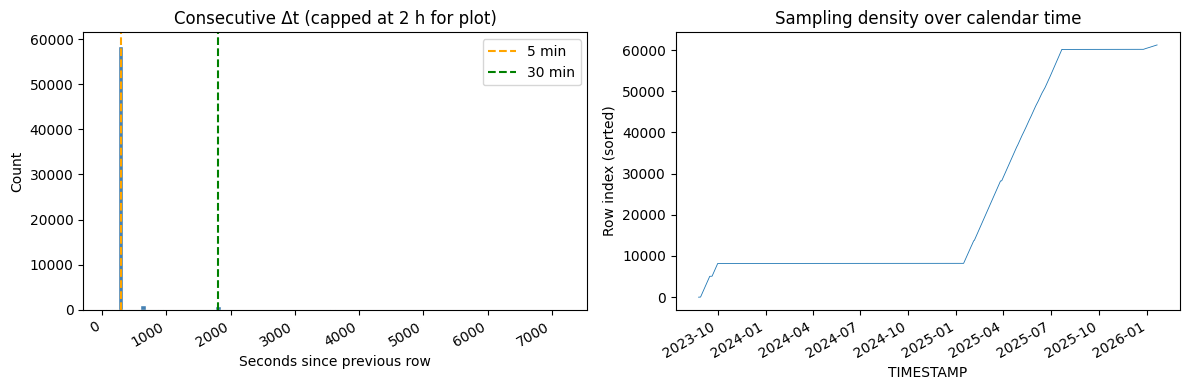

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of consecutive gaps (cap x-axis for readability)
plot_diffs = diffs.clip(upper=7200)
axes[0].hist(plot_diffs, bins=80, color="steelblue", edgecolor="white")
axes[0].axvline(300, color="orange", ls="--", label="5 min")
axes[0].axvline(TARGET_STEP_SECONDS, color="green", ls="--", label="30 min")
axes[0].set_xlabel("Seconds since previous row")
axes[0].set_ylabel("Count")
axes[0].set_title("Consecutive Δt (capped at 2 h for plot)")
axes[0].legend()

# Row index vs time (shows outages as flat jumps)
axes[1].plot(df_raw[TIME_COL], np.arange(len(df_raw)), lw=0.6)
axes[1].set_xlabel("TIMESTAMP")
axes[1].set_ylabel("Row index (sorted)")
axes[1].set_title("Sampling density over calendar time")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2. Downsample to 30 minutes

In [13]:
df_30 = apply_downsample(df_raw, DOWNSAMPLE_METHOD)

# Sanity check: row-pick methods must be exact subsets of the original table
if DOWNSAMPLE_METHOD.startswith("pick_") or DOWNSAMPLE_METHOD == "strict_incoming":
    merged = df_30.merge(
        df_raw.drop_duplicates(subset=[TIME_COL]),
        on=list(df_30.columns),
        how="left",
        indicator=True,
    )
    n_bad = int((merged["_merge"] != "both").sum())
    print(f"Rows matching original measurements exactly: {len(df_30) - n_bad} / {len(df_30)}")
    if n_bad:
        print("WARNING: some output rows differ from the source CSV.")

out_diffs = df_30[TIME_COL].diff().dt.total_seconds().dropna()
print(f"Method: {DOWNSAMPLE_METHOD}")
print(f"Rows: {len(df_raw):,} -> {len(df_30):,} ({100 * len(df_30) / max(len(df_raw), 1):.1f}% of original)")
if len(out_diffs):
    print(
        f"Output median Δt: {out_diffs.median():.0f} s "
        f"({out_diffs.median() / 60:.0f} min)"
    )
    within = ((out_diffs >= TARGET_STEP_SECONDS - STEP_TOL_SECONDS) & (
        out_diffs <= TARGET_STEP_SECONDS + STEP_TOL_SECONDS
    )).mean()
    print(f"Output steps within 30 min ± {STEP_TOL_SECONDS:.0f} s: {100 * within:.1f}%")

display(df_30[[TIME_COL, "Acceleration RMS"]].head(8))
display(df_30[[TIME_COL, "Acceleration RMS"]].tail(8))

Rows matching original measurements exactly: 11353 / 11353
Method: pick_last_in_bin
Rows: 61,251 -> 11,353 (18.5% of original)
Output median Δt: 1800 s (30 min)
Output steps within 30 min ± 60 s: 94.6%


,TIMESTAMP,Acceleration RMS
0,2023-08-25 16:28:00,0.94
1,2023-08-29 09:27:00,0.14
2,2023-08-29 09:57:00,0.18
3,2023-08-29 10:27:00,0.16
4,2023-08-29 10:57:00,0.16
5,2023-08-29 11:27:00,0.17
6,2023-08-29 11:57:00,0.19
7,2023-08-29 12:27:00,0.16


,TIMESTAMP,Acceleration RMS
11345,2026-01-20 06:15:00,3.45
11346,2026-01-20 06:45:00,3.13
11347,2026-01-20 07:45:00,4.07
11348,2026-01-20 08:15:00,3.23
11349,2026-01-20 08:45:00,3.25
11350,2026-01-20 09:15:00,3.31
11351,2026-01-20 09:45:00,3.51
11352,2026-01-20 10:15:00,3.58


## 3. Write outputs (single file or batch)

In [14]:
def downsample_file(path: Path, method: str) -> tuple[pd.DataFrame, int, int]:
    df = load_sensor_csv(path)
    n_before = len(df)
    out = apply_downsample(df, method)
    return out, n_before, len(out)


def list_csv_files(data_dir: Path, *, recursive: bool) -> list[Path]:
    data_dir = Path(data_dir)
    if recursive:
        return sorted(data_dir.rglob("*.csv"))
    return sorted(data_dir.glob("*.csv"))


OUT_DIR.mkdir(parents=True, exist_ok=True)
paths = list_csv_files(DATA_DIR, recursive=RECURSIVE) if BATCH_ALL_CSVS else [SAMPLE_CSV]

summary_rows = []
for path in paths:
    if path.name.startswith("_"):
        continue
    try:
        out_df, n_before, n_after = downsample_file(path, DOWNSAMPLE_METHOD)
        rel = path.relative_to(DATA_DIR)
        out_name = "__".join(rel.parts) if len(rel.parts) > 1 else rel.name
        if OUT_STEM_SUFFIX:
            p = Path(out_name)
            if not p.stem.endswith(OUT_STEM_SUFFIX):
                out_name = f"{p.stem}{OUT_STEM_SUFFIX}{p.suffix}"
        out_path = OUT_DIR / out_name
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_df.to_csv(out_path, index=False)
        med_dt = (
            out_df[TIME_COL].diff().dt.total_seconds().dropna().median()
            if len(out_df) > 1
            else float("nan")
        )
        summary_rows.append(
            {
                "source": str(path),
                "output": str(out_path),
                "method": DOWNSAMPLE_METHOD,
                "rows_before": n_before,
                "rows_after": n_after,
                "median_dt_seconds_after": med_dt,
            }
        )
        print(f"OK {path.name}: {n_before:,} -> {n_after:,} (median Δt {med_dt:.0f} s) -> {out_path.name}")
    except Exception as exc:
        summary_rows.append({"source": str(path), "error": str(exc)})
        print(f"FAIL {path.name}: {exc}")

summary = pd.DataFrame(summary_rows)
summary_path = OUT_DIR / "_downsample_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"\nWrote summary: {summary_path}")
display(summary)

OK AHU_2_9_Blower_DE_A.csv: 61,251 -> 11,353 (median Δt 1800 s) -> AHU_2_9_Blower_DE_A.csv
OK AHU_2_9_Blower_DE_V.csv: 84,001 -> 15,158 (median Δt 1800 s) -> AHU_2_9_Blower_DE_V.csv
OK AHU_2_9_Blower_DE_Vibration_X.csv: 147,312 -> 27,925 (median Δt 1800 s) -> AHU_2_9_Blower_DE_Vibration_X.csv
OK AHU_2_9_Blower_NDE_A.csv: 90,735 -> 15,996 (median Δt 1800 s) -> AHU_2_9_Blower_NDE_A.csv
OK AHU_2_9_Blower_NDE_H.csv: 56,470 -> 14,055 (median Δt 1800 s) -> AHU_2_9_Blower_NDE_H.csv
OK AHU_2_9_Blower_NDE_V.csv: 82,905 -> 15,722 (median Δt 1800 s) -> AHU_2_9_Blower_NDE_V.csv
OK AHU_2_9_motor_DE_H.csv: 63,954 -> 12,363 (median Δt 1800 s) -> AHU_2_9_motor_DE_H.csv
OK AHU_2_9_motor_NDE_H.csv: 73,344 -> 14,926 (median Δt 1800 s) -> AHU_2_9_motor_NDE_H.csv
OK Jan2Jun.csv: 105,209 -> 6,256 (median Δt 1800 s) -> Jan2Jun.csv

Wrote summary: c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_frequency\_downsample_summary.csv


,source,output,method,rows_before,rows_after,median_dt_seconds_after
0,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,61251,11353,1800.0
1,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,84001,15158,1800.0
2,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,147312,27925,1800.0
3,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,90735,15996,1800.0
4,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,56470,14055,1800.0
5,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,82905,15722,1800.0
6,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,63954,12363,1800.0
7,c:\Users\NGYX\Desktop\Murata_NGYX\data\AHU_2_9...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,73344,14926,1800.0
8,c:\Users\NGYX\Desktop\Murata_NGYX\data\Jan2Jun...,c:\Users\NGYX\Desktop\Murata_NGYX\data_30mins_...,pick_last_in_bin,105209,6256,1800.0
